In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Tsunami.csv")
df

,Year,Mo,Dy,Tsunami Event Validity,Tsunami Cause Code,Earthquake Magnitude,Country,Area,Region,Location Name,Latitude,Longitude,Maximum Water Height (m),Number of Runups,Tsunami Magnitude (Iida),Deaths,Death Description,Damage ($Mil),Damage Description,Houses Destroyed Description
0,1751.0,5.0,20.0,4.0,3.0,6.6,JAPAN,NaN,85.0,NW. HONSHU ISLAND,37.200,138.100,0.92,1.0,1.0,2100.0,4.0,NaN,4.0,4.0
1,1751.0,5.0,25.0,4.0,1.0,8.5,CHILE,NaN,89.0,CENTRAL CHILE,-37.000,-73.000,3.50,7.0,1.8,65.0,2.0,NaN,1.0,NaN
2,1751.0,10.0,18.0,3.0,1.0,7.3,DOMINICAN REPUBLIC,NaN,74.0,AZUA DE COMPOSTELA,18.500,-70.700,0.92,3.0,0.6,NaN,NaN,NaN,3.0,3.0
3,1754.0,8.0,18.0,3.0,1.0,6.5,INDONESIA,NaN,83.0,BANDA SEA,-3.500,128.500,0.92,3.0,0.6,NaN,NaN,NaN,NaN,NaN
4,1754.0,9.0,1.0,3.0,1.0,7.2,MEXICO,NaN,88.0,S. MEXICO,16.800,-99.200,4.00,1.0,2.0,NaN,NaN,NaN,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2023.0,10.0,5.0,4.0,1.0,6.1,JAPAN,NaN,85.0,"IZU ISLANDS, JAPAN",29.940,139.950,0.30,1.0,0.6,NaN,NaN,NaN,NaN,NaN
1268,2023.0,10.0,8.0,4.0,0.0,7.2,JAPAN,NaN,85.0,"IZU ISLANDS, JAPAN",29.700,139.900,0.30,12.0,0.6,NaN,NaN,NaN,NaN,NaN
1269,2023.0,11.0,22.0,4.0,1.0,6.7,VANUATU,NaN,82.0,VANUATU ISLANDS,-14.985,167.983,0.06,1.0,0.6,NaN,NaN,NaN,NaN,NaN
1270,2023.0,12.0,2.0,4.0,1.0,7.6,PHILIPPINES,NaN,84.0,E. MINDANAO ISLAND,8.527,126.449,0.32,29.0,0.6,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          1272 non-null   float64
 1   Mo                            1272 non-null   float64
 2   Dy                            1272 non-null   float64
 3   Tsunami Event Validity        1272 non-null   float64
 4   Tsunami Cause Code            1272 non-null   float64
 5   Earthquake Magnitude          1272 non-null   float64
 6   Country                       1272 non-null   object 
 7   Area                          129 non-null    object 
 8   Region                        1272 non-null   float64
 9   Location Name                 1272 non-null   object 
 10  Latitude                      1226 non-null   float64
 11  Longitude                     1226 non-null   float64
 12  Maximum Water Height (m)      1272 non-null   float64
 13  Num

In [7]:
threshold = 0.8 * len(df)
df = df.dropna(axis=1, thresh=threshold)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      1272 non-null   float64
 1   Mo                        1272 non-null   float64
 2   Dy                        1272 non-null   float64
 3   Tsunami Event Validity    1272 non-null   float64
 4   Tsunami Cause Code        1272 non-null   float64
 5   Earthquake Magnitude      1272 non-null   float64
 6   Country                   1272 non-null   object 
 7   Region                    1272 non-null   float64
 8   Location Name             1272 non-null   object 
 9   Latitude                  1226 non-null   float64
 10  Longitude                 1226 non-null   float64
 11  Maximum Water Height (m)  1272 non-null   float64
 12  Number of Runups          1272 non-null   float64
 13  Tsunami Magnitude (Iida)  1272 non-null   float64
dtypes: float

In [11]:
df.drop(df[(df['Latitude'].isna()) | (df['Longitude'].isna()) | (df['Latitude'] == 0) | (df['Longitude'] == 0)].index, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1225 entries, 0 to 1271
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      1225 non-null   float64
 1   Mo                        1225 non-null   float64
 2   Dy                        1225 non-null   float64
 3   Tsunami Event Validity    1225 non-null   float64
 4   Tsunami Cause Code        1225 non-null   float64
 5   Earthquake Magnitude      1225 non-null   float64
 6   Country                   1225 non-null   object 
 7   Region                    1225 non-null   float64
 8   Location Name             1225 non-null   object 
 9   Latitude                  1225 non-null   float64
 10  Longitude                 1225 non-null   float64
 11  Maximum Water Height (m)  1225 non-null   float64
 12  Number of Runups          1225 non-null   float64
 13  Tsunami Magnitude (Iida)  1225 non-null   float64
dtypes: float64(12

In [13]:
df.rename(columns={'Mo': 'Month', 'Dy': 'Day'}, inplace=True)
df

,Year,Month,Day,Tsunami Event Validity,Tsunami Cause Code,Earthquake Magnitude,Country,Region,Location Name,Latitude,Longitude,Maximum Water Height (m),Number of Runups,Tsunami Magnitude (Iida)
0,1751.0,5.0,20.0,4.0,3.0,6.6,JAPAN,85.0,NW. HONSHU ISLAND,37.200,138.100,0.92,1.0,1.0
1,1751.0,5.0,25.0,4.0,1.0,8.5,CHILE,89.0,CENTRAL CHILE,-37.000,-73.000,3.50,7.0,1.8
2,1751.0,10.0,18.0,3.0,1.0,7.3,DOMINICAN REPUBLIC,74.0,AZUA DE COMPOSTELA,18.500,-70.700,0.92,3.0,0.6
3,1754.0,8.0,18.0,3.0,1.0,6.5,INDONESIA,83.0,BANDA SEA,-3.500,128.500,0.92,3.0,0.6
4,1754.0,9.0,1.0,3.0,1.0,7.2,MEXICO,88.0,S. MEXICO,16.800,-99.200,4.00,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2023.0,10.0,5.0,4.0,1.0,6.1,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.940,139.950,0.30,1.0,0.6
1268,2023.0,10.0,8.0,4.0,0.0,7.2,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.700,139.900,0.30,12.0,0.6
1269,2023.0,11.0,22.0,4.0,1.0,6.7,VANUATU,82.0,VANUATU ISLANDS,-14.985,167.983,0.06,1.0,0.6
1270,2023.0,12.0,2.0,4.0,1.0,7.6,PHILIPPINES,84.0,E. MINDANAO ISLAND,8.527,126.449,0.32,29.0,0.6


In [15]:
df = df.drop(columns=['Tsunami Event Validity', 'Tsunami Cause Code'])

In [17]:
df.rename(columns={'Maximum Water Height (m)': 'Height', 'Number of Runups': 'N_Runups', 'Tsunami Magnitude (Iida)': 'Tsunami_mag', 'Earthquake Magnitude': 'Earthquake_mag'}, inplace=True)

In [19]:
df = df[df['Height'] < 100]

In [21]:
df = df[df['N_Runups'] < 300]

In [154]:
df

,Year,Month,Day,Earthquake_mag,Country,Region,Location Name,Latitude,Longitude,Height,N_Runups,Tsunami_mag
0,1751.0,5.0,20.0,6.6,JAPAN,85.0,NW. HONSHU ISLAND,37.200,138.100,0.92,1.0,1.0
1,1751.0,5.0,25.0,8.5,CHILE,89.0,CENTRAL CHILE,-37.000,-73.000,3.50,7.0,1.8
2,1751.0,10.0,18.0,7.3,DOMINICAN REPUBLIC,74.0,AZUA DE COMPOSTELA,18.500,-70.700,0.92,3.0,0.6
3,1754.0,8.0,18.0,6.5,INDONESIA,83.0,BANDA SEA,-3.500,128.500,0.92,3.0,0.6
4,1754.0,9.0,1.0,7.2,MEXICO,88.0,S. MEXICO,16.800,-99.200,4.00,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2023.0,10.0,5.0,6.1,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.940,139.950,0.30,1.0,0.6
1268,2023.0,10.0,8.0,7.2,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.700,139.900,0.30,12.0,0.6
1269,2023.0,11.0,22.0,6.7,VANUATU,82.0,VANUATU ISLANDS,-14.985,167.983,0.06,1.0,0.6
1270,2023.0,12.0,2.0,7.6,PHILIPPINES,84.0,E. MINDANAO ISLAND,8.527,126.449,0.32,29.0,0.6


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1206.0,1942.841625,66.261125,1751.000,1901.00000,1961.0000,1997.00000,2023.000
Month,1206.0,6.442786,3.445793,1.000,3.00000,7.0000,9.00000,12.000
Day,1206.0,15.117745,8.710907,1.000,8.00000,15.0000,22.00000,31.000
Earthquake_mag,1206.0,7.133167,0.655961,3.700,6.80000,7.2000,7.50000,8.800
Region,1206.0,77.732172,12.969306,30.000,74.00000,83.0000,85.00000,89.000
Latitude,1206.0,16.860566,27.953410,-62.877,-5.40900,19.2360,38.78900,78.370
Longitude,1206.0,50.868439,111.219763,-179.971,-66.89025,118.5445,142.61425,179.444
Height,1206.0,2.968076,7.774656,0.010,0.30000,0.9200,2.00000,90.000
N_Runups,1206.0,11.131012,30.246227,0.000,1.00000,2.0000,7.00000,294.000
Tsunami_mag,1206.0,0.507181,1.409772,-4.640,0.60000,0.6000,0.60000,6.400


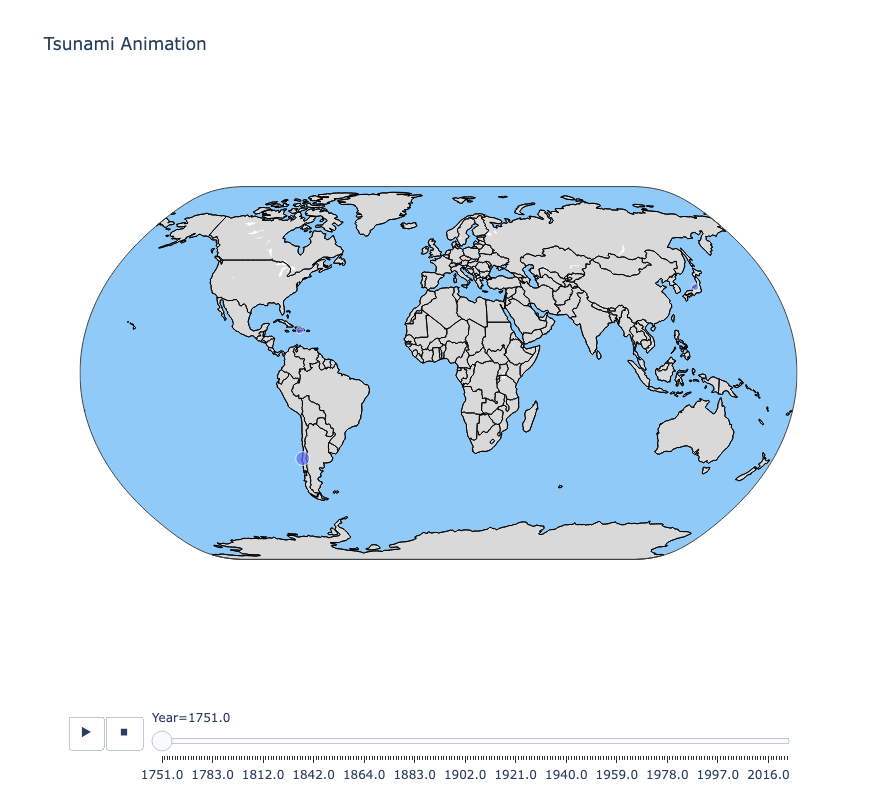

In [156]:
fig = px.scatter_geo(df, 
                     lon='Longitude', 
                     lat='Latitude',
                     size='Height',
                     size_max = 50,
                     hover_name='Region',
                     animation_frame='Year',
                     projection='natural earth',
                     title='Tsunami Animation')

fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="rgb(217, 217, 217)",
    showocean=True, oceancolor="rgb(144, 202, 249)",
    showcountries=True, countrycolor="rgb(5, 5, 5)"
)

fig.update_layout(
    height=800,  
    width= 800   
)

fig.show()

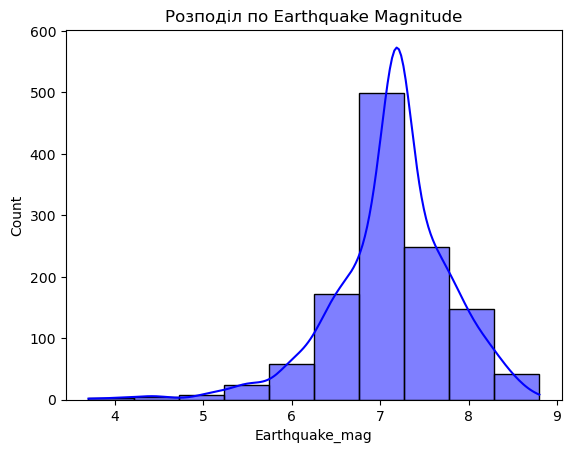

In [27]:
sns.histplot(data=df, x='Earthquake_mag', bins=10, kde=True, color='blue')
plt.title('Розподіл по Earthquake Magnitude')
plt.show()

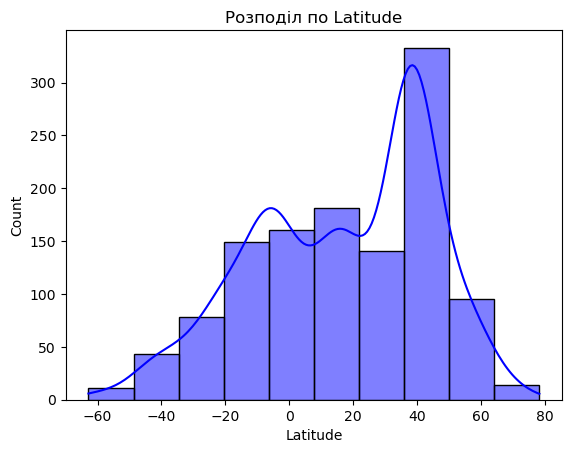

In [29]:
sns.histplot(data=df, x='Latitude', bins=10, kde=True, color='blue')
plt.title('Розподіл по Latitude')
plt.show()

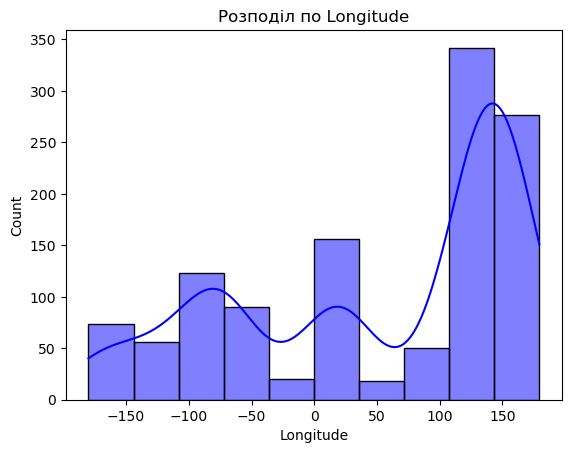

In [31]:
sns.histplot(data=df, x='Longitude', bins=10, kde=True, color='blue')
plt.title('Розподіл по Longitude')
plt.show()

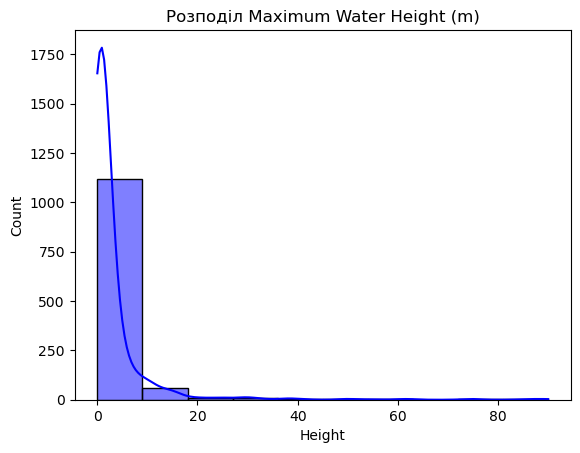

In [33]:
sns.histplot(data=df, x='Height', bins=10, kde=True, color='blue')
plt.title('Розподіл Maximum Water Height (m)')
plt.show()

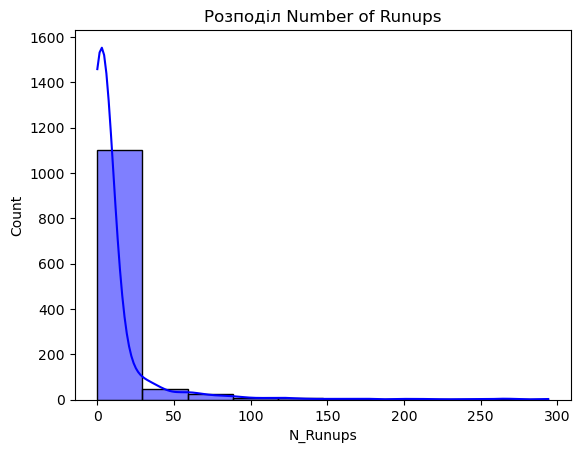

In [35]:
sns.histplot(data=df, x='N_Runups', bins=10, kde=True, color='blue')
plt.title('Розподіл Number of Runups')
plt.show()

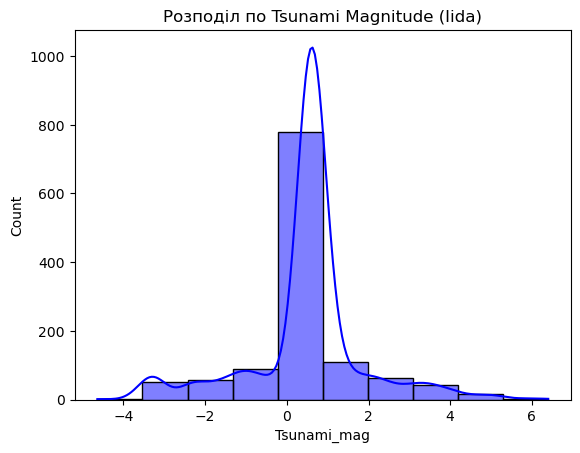

In [37]:
sns.histplot(data=df, x='Tsunami_mag', bins=10, kde=True, color='blue')
plt.title('Розподіл по Tsunami Magnitude (Iida)')
plt.show()

In [39]:
df[['Earthquake_mag','Latitude', 'Longitude', 'Height', 'N_Runups', 'Tsunami_mag']].corr()

,Earthquake_mag,Latitude,Longitude,Height,N_Runups,Tsunami_mag
Earthquake_mag,1.000000,-0.198906,-0.052316,0.161070,0.302914,0.187550
Latitude,-0.198906,1.000000,-0.060519,0.089973,0.013421,-0.067400
Longitude,-0.052316,-0.060519,1.000000,-0.047331,0.033845,-0.027660
Height,0.161070,0.089973,-0.047331,1.000000,0.274381,0.395259
N_Runups,0.302914,0.013421,0.033845,0.274381,1.000000,0.239406
Tsunami_mag,0.187550,-0.067400,-0.027660,0.395259,0.239406,1.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1206 entries, 0 to 1271
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            1206 non-null   float64
 1   Month           1206 non-null   float64
 2   Day             1206 non-null   float64
 3   Earthquake_mag  1206 non-null   float64
 4   Country         1206 non-null   object 
 5   Region          1206 non-null   float64
 6   Location Name   1206 non-null   object 
 7   Latitude        1206 non-null   float64
 8   Longitude       1206 non-null   float64
 9   Height          1206 non-null   float64
 10  N_Runups        1206 non-null   float64
 11  Tsunami_mag     1206 non-null   float64
dtypes: float64(10), object(2)
memory usage: 122.5+ KB


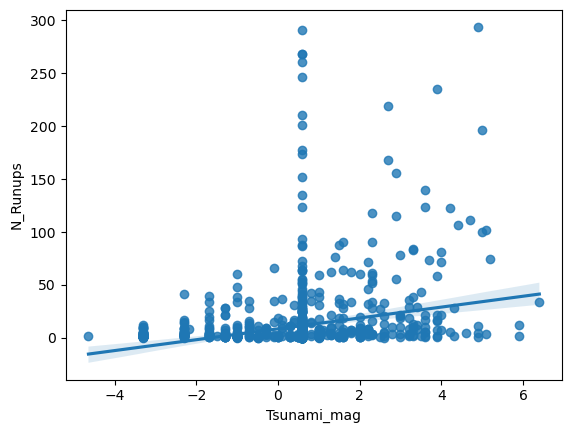

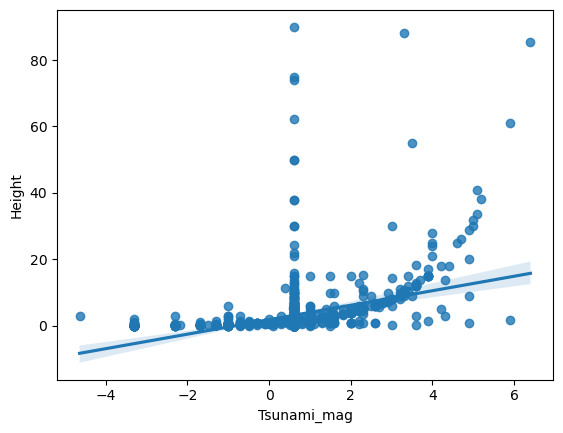

In [43]:
sns.regplot(x='Tsunami_mag', y='N_Runups', data=df)
plt.show()
sns.regplot(x='Tsunami_mag', y='Height', data=df)
plt.show()

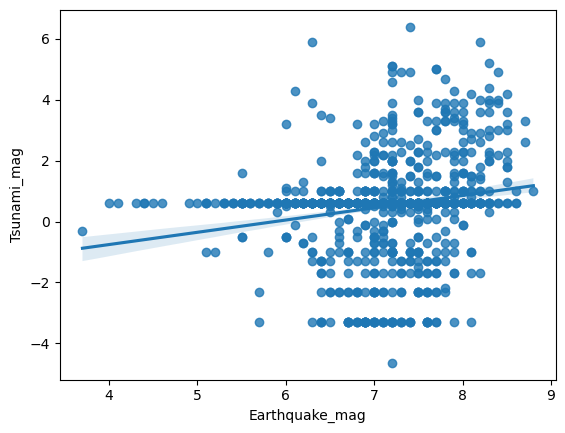

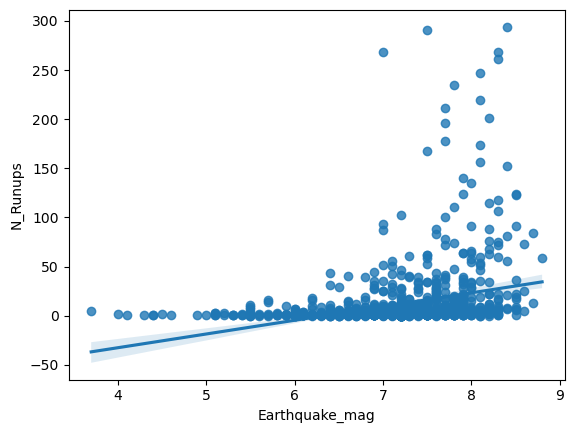

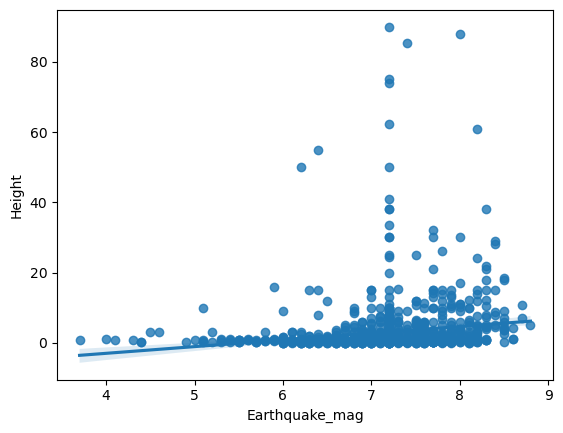

In [45]:
sns.regplot(x='Earthquake_mag', y='Tsunami_mag', data=df)
plt.show()
sns.regplot(x='Earthquake_mag', y='N_Runups', data=df)
plt.show()
sns.regplot(x='Earthquake_mag', y='Height', data=df)
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1206 entries, 0 to 1271
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            1206 non-null   float64
 1   Month           1206 non-null   float64
 2   Day             1206 non-null   float64
 3   Earthquake_mag  1206 non-null   float64
 4   Country         1206 non-null   object 
 5   Region          1206 non-null   float64
 6   Location Name   1206 non-null   object 
 7   Latitude        1206 non-null   float64
 8   Longitude       1206 non-null   float64
 9   Height          1206 non-null   float64
 10  N_Runups        1206 non-null   float64
 11  Tsunami_mag     1206 non-null   float64
dtypes: float64(10), object(2)
memory usage: 122.5+ KB


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.experimental import enable_hist_gradient_boosting 
from sklearn.ensemble import HistGradientBoostingClassifier

# DECISION TREE REGRESSOR

In [160]:
X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(df[['Tsunami_mag', 'Earthquake_mag', 'N_Runups']], df['Height'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)

regression_dt_0 = DecisionTreeRegressor(random_state=42)

regression_dt_0.fit(X_train_scaled_reg_0, y_train_reg_0)


y_pred_reg_0 = regression_dt_0.predict(X_test_scaled_reg_0)

In [168]:
reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)

print("Regression Model 0 - R^2 Score:", reg_0_r2)

Regression Model 0 - R^2 Score: 0.3679229144005507


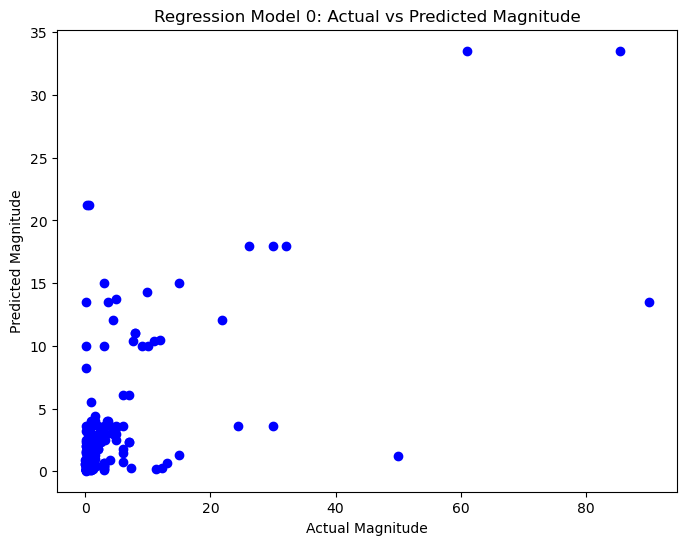

In [117]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

In [202]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName):
    width = 10
    height = 8
    plt.figure(figsize=(width, height))

    ax1 = sns.distplot(RedFunction, hist=False, color="r", label=RedName)
    ax2 = sns.distplot(BlueFunction, hist=False, color="b", label=BlueName, ax=ax1)


    plt.show()
    plt.close()

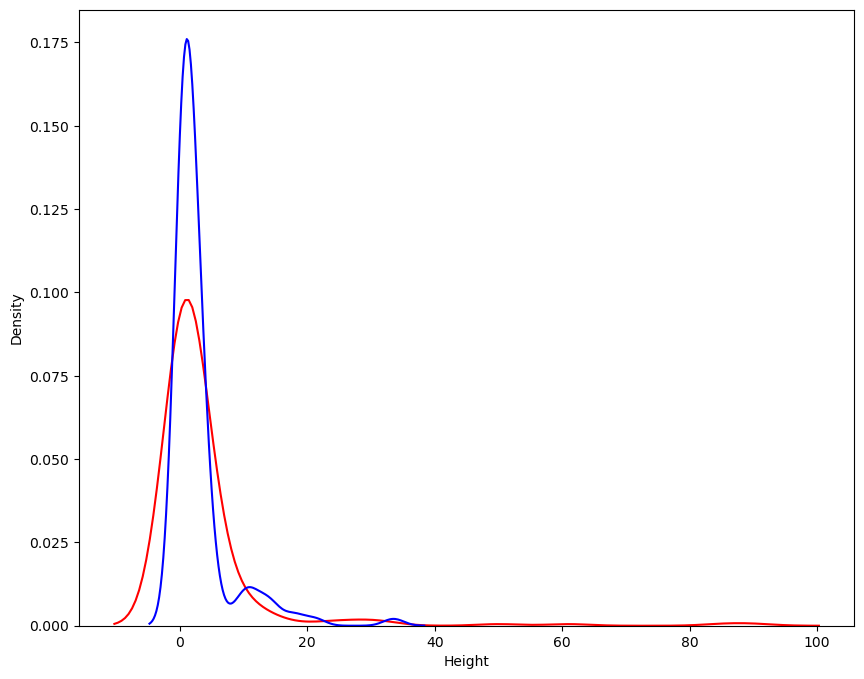

In [204]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

DistributionPlot(y_test_reg_0, y_pred_reg_0, "Actual Values (Train)", "Predicted Values (Train)")

In [65]:
df

,Year,Month,Day,Earthquake_mag,Country,Region,Location Name,Latitude,Longitude,Height,N_Runups,Tsunami_mag
0,1751.0,5.0,20.0,6.6,JAPAN,85.0,NW. HONSHU ISLAND,37.200,138.100,0.92,1.0,1.0
1,1751.0,5.0,25.0,8.5,CHILE,89.0,CENTRAL CHILE,-37.000,-73.000,3.50,7.0,1.8
2,1751.0,10.0,18.0,7.3,DOMINICAN REPUBLIC,74.0,AZUA DE COMPOSTELA,18.500,-70.700,0.92,3.0,0.6
3,1754.0,8.0,18.0,6.5,INDONESIA,83.0,BANDA SEA,-3.500,128.500,0.92,3.0,0.6
4,1754.0,9.0,1.0,7.2,MEXICO,88.0,S. MEXICO,16.800,-99.200,4.00,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2023.0,10.0,5.0,6.1,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.940,139.950,0.30,1.0,0.6
1268,2023.0,10.0,8.0,7.2,JAPAN,85.0,"IZU ISLANDS, JAPAN",29.700,139.900,0.30,12.0,0.6
1269,2023.0,11.0,22.0,6.7,VANUATU,82.0,VANUATU ISLANDS,-14.985,167.983,0.06,1.0,0.6
1270,2023.0,12.0,2.0,7.6,PHILIPPINES,84.0,E. MINDANAO ISLAND,8.527,126.449,0.32,29.0,0.6


In [184]:
input_df = pd.DataFrame({
    'Tsunami_mag': [3.6],
    'Earthquake_mag': [8.5],
    'N_Runups': [124.0]
})

input_features = scaler_reg.transform(input_df)

predicted_height = regression_dt_0.predict(input_features)



print("Predicted height:", predicted_height[0])

Predicted height: 18.3


In [172]:
df[(df['Tsunami_mag'] == 1.8) & (df['Earthquake_mag'] == 8.5) & (df['N_Runups'] == 7.0)]

,Year,Month,Day,Earthquake_mag,Country,Region,Location Name,Latitude,Longitude,Height,N_Runups,Tsunami_mag
1,1751.0,5.0,25.0,8.5,CHILE,89.0,CENTRAL CHILE,-37.0,-73.0,3.5,7.0,1.8


In [206]:
df[(df['Height'] > 89)]

,Year,Month,Day,Earthquake_mag,Country,Region,Location Name,Latitude,Longitude,Height,N_Runups,Tsunami_mag
1180,2017.0,6.0,17.0,7.2,GREENLAND,72.0,"KARRAT FJORD, GREENLAND",71.813,-52.569,90.0,5.0,0.6


# Random Forest Regressor

In [210]:
X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(df[['Tsunami_mag', 'Earthquake_mag', 'N_Runups']], df['Height'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)

regression_dt_0 = RandomForestRegressor(n_estimators=5, random_state=42)

regression_dt_0.fit(X_train_scaled_reg_0, y_train_reg_0)


y_pred_reg_0 = regression_dt_0.predict(X_test_scaled_reg_0)

In [212]:
reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)

print("Regression Model 0 - R^2 Score:", reg_0_r2)

Regression Model 0 - R^2 Score: 0.3610650297867083


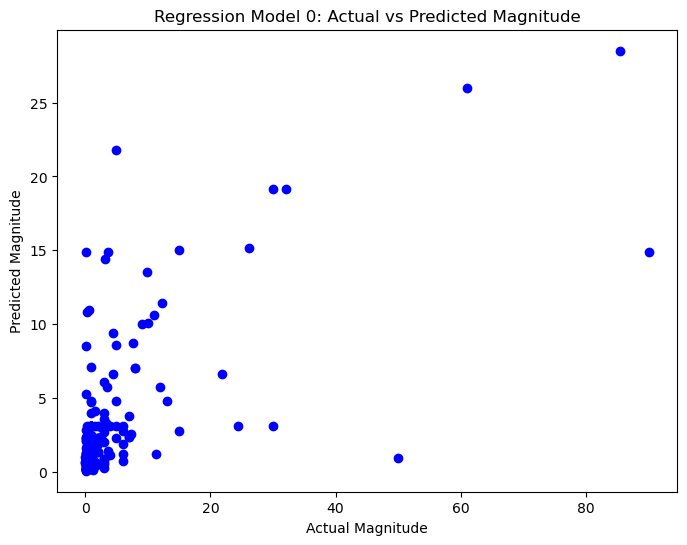

In [129]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

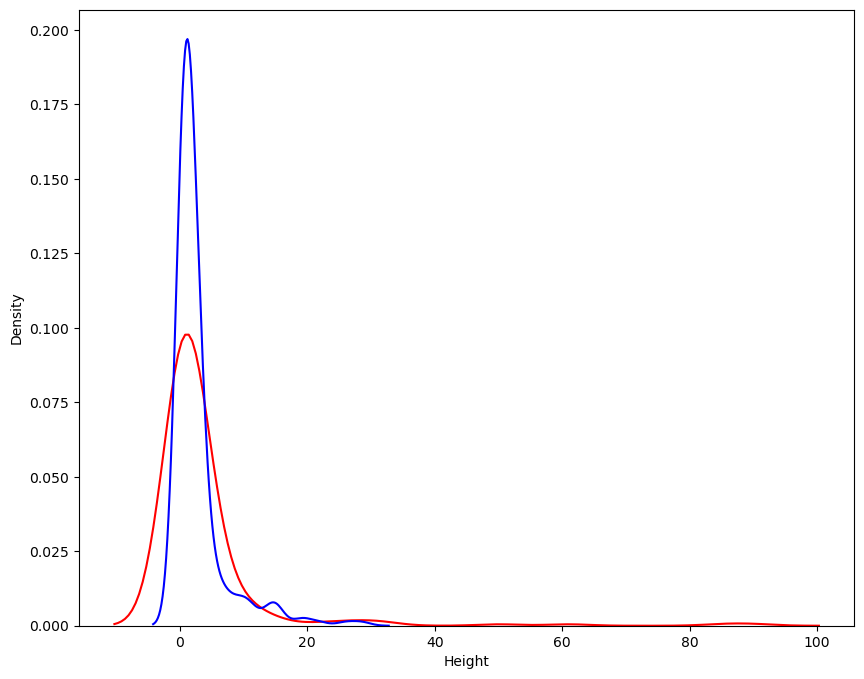

In [222]:
DistributionPlot(y_test_reg_0, y_pred_reg_0, "Actual Values (Train)", "Predicted Values (Train)")

In [220]:
input_df = pd.DataFrame({
    'Tsunami_mag': [3.6],
    'Earthquake_mag': [8.5],
    'N_Runups': [124.0]
})

input_features = scaler_reg.transform(input_df)

predicted_height = regression_dt_0.predict(input_features)



print("Predicted height:", predicted_height[0])

Predicted height: 16.64


# ADA BOOST

In [224]:
X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(df[['Tsunami_mag', 'Earthquake_mag', 'N_Runups']], df['Height'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)

regression_dt_0 = AdaBoostRegressor(n_estimators=50, random_state=42)

regression_dt_0.fit(X_train_scaled_reg_0, y_train_reg_0)


y_pred_reg_0 = regression_dt_0.predict(X_test_scaled_reg_0)

In [230]:
reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)

print("Regression Model 0 - R^2 Score:", reg_0_r2)

NameError: name 'score' is not defined

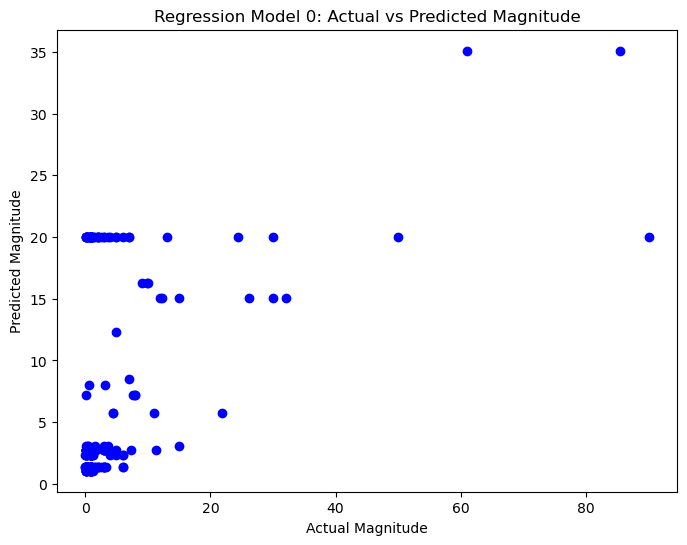

In [137]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

In [228]:
input_df = pd.DataFrame({
    'Tsunami_mag': [3.6],
    'Earthquake_mag': [8.5],
    'N_Runups': [124.0]
})

input_features = scaler_reg.transform(input_df)

predicted_height = regression_dt_0.predict(input_features)



print("Predicted height:", predicted_height[0])

Predicted height: 15.066410256410254


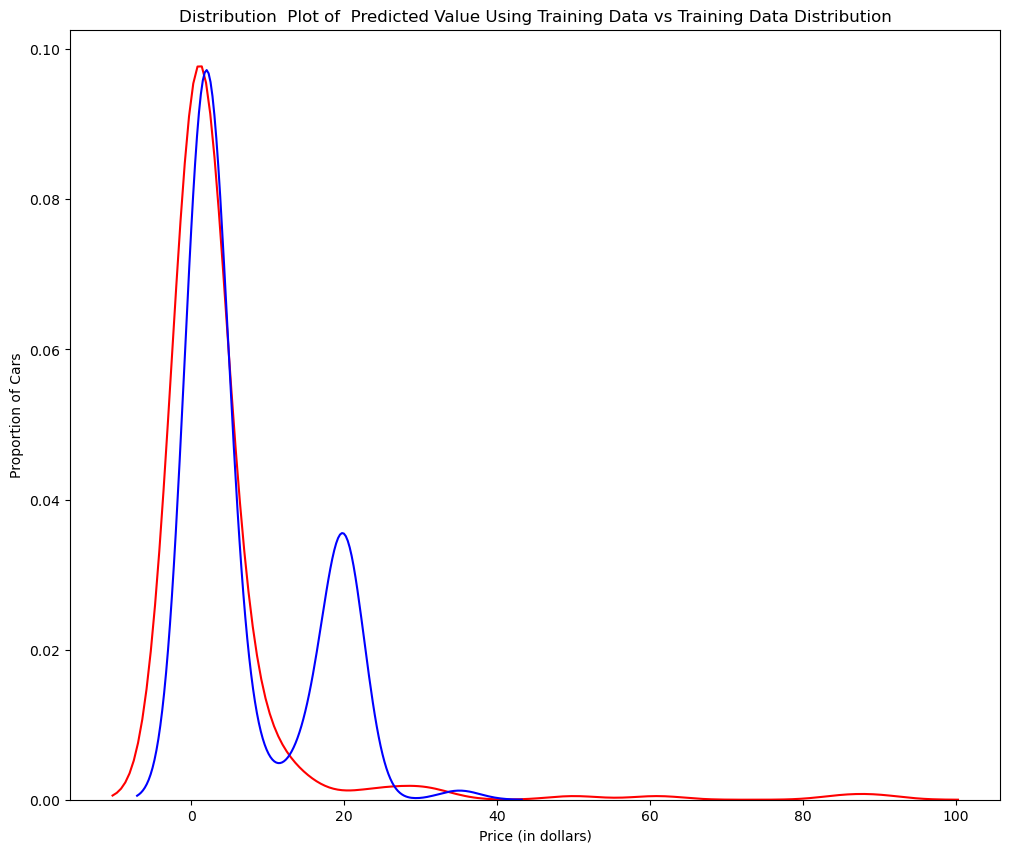

In [141]:
Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_test_reg_0, y_pred_reg_0, "Actual Values (Train)", "Predicted Values (Train)", Title)

# GradientBoostingRegressor

In [232]:
from sklearn.ensemble import GradientBoostingRegressor

X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(df[['Tsunami_mag', 'Earthquake_mag', 'N_Runups']], df['Height'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)

regression_dt_0 = GradientBoostingRegressor(random_state=42)

regression_dt_0.fit(X_train_scaled_reg_0, y_train_reg_0)


y_pred_reg_0 = regression_dt_0.predict(X_test_scaled_reg_0)

In [234]:
reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)

print("Regression Model 0 - R^2 Score:", reg_0_r2)

Regression Model 0 - R^2 Score: 0.34826333372131446


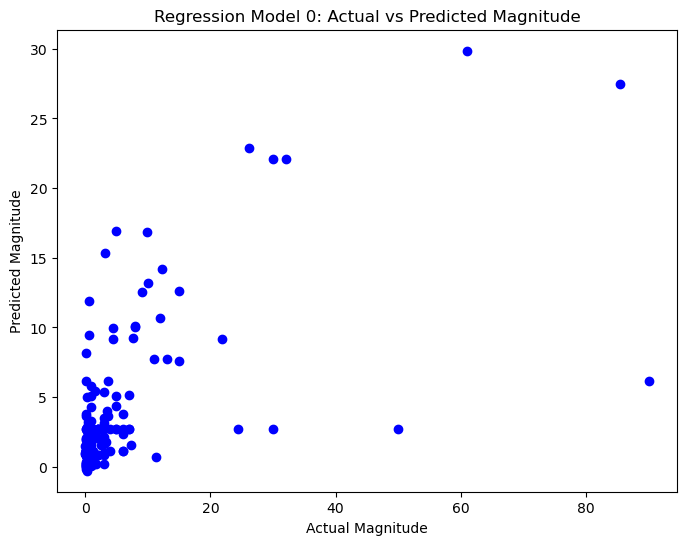

In [147]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

In [242]:
input_df = pd.DataFrame({
    'Tsunami_mag': [3.6],
    'Earthquake_mag': [8.5],
    'N_Runups': [124.0]
})

input_features = scaler_reg.transform(input_df)

predicted_height = regression_dt_0.predict(input_features)



print("Predicted height:", predicted_height[0])

Predicted height: 15.823426839657039


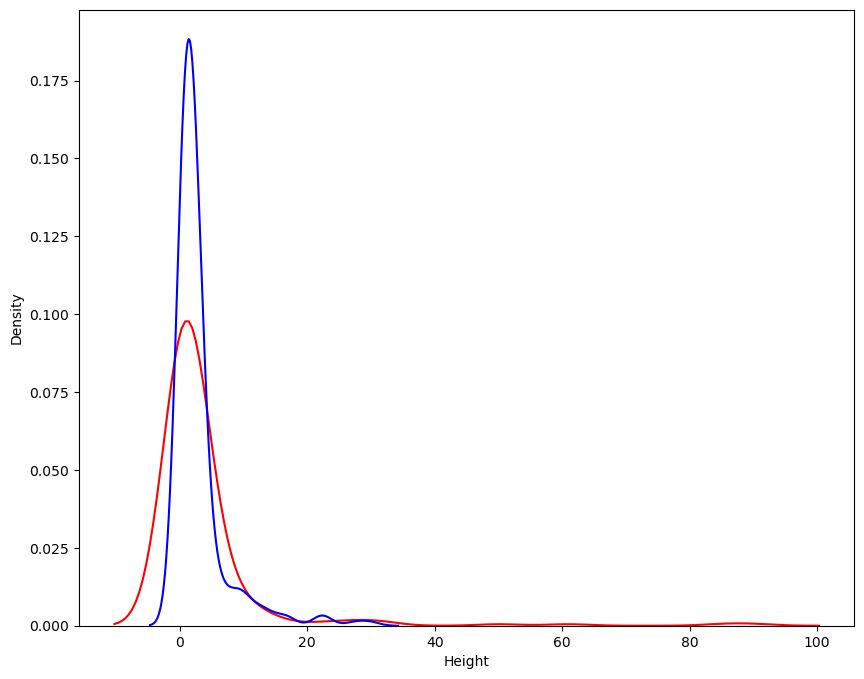

In [244]:
DistributionPlot(y_test_reg_0, y_pred_reg_0, "Actual Values (Train)", "Predicted Values (Train)")